In [2]:
import os
import glob
import random
import shutil

def select_consecutive_images(
    root_dir,
    dest_dir,
    profiles_per_cruise=5,
    images_per_profile=200,
    image_ext=".png"
):
    """
    For each cruise, randomly select profiles_per_cruise profiles,
    then select images_per_profile consecutive images from each profile,
    and copy them to dest_dir/cruise.
    """
    os.makedirs(dest_dir, exist_ok=True)
    cruises = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    for cruise in cruises:
        cruise_path = os.path.join(root_dir, cruise)
        profiles_root = os.path.join(cruise_path, f"{cruise}-PISCO-Profiles")
        if not os.path.isdir(profiles_root):
            continue
        profiles = [d for d in os.listdir(profiles_root) if os.path.isdir(os.path.join(profiles_root, d))]
        if len(profiles) < profiles_per_cruise:
            print(f"Not enough profiles in {cruise}, skipping.")
            continue
        selected_profiles = random.sample(profiles, profiles_per_cruise)
        cruise_dest = os.path.join(dest_dir, cruise)
        os.makedirs(cruise_dest, exist_ok=True)
        for profile in selected_profiles:
            profile_path = os.path.join(profiles_root, profile)
            # Check for PNG or {profile}_Images-PNG subfolders
            png_folder = os.path.join(profile_path, "PNG")
            images_png_folder = os.path.join(profile_path, f"{profile}_Images-PNG")
            if os.path.isdir(png_folder):
                images = glob.glob(os.path.join(png_folder, f"*{image_ext}"))
            elif os.path.isdir(images_png_folder):
                images = glob.glob(os.path.join(images_png_folder, f"*{image_ext}"))
            else:
                images = glob.glob(os.path.join(profile_path, f"*{image_ext}"))
            images = sorted(images)  # Sort for consecutive order
            if len(images) < images_per_profile:
                print(f"Not enough images in {profile} of {cruise}, skipping.")
                continue
            # Pick a random start index for consecutive batch
            start_idx = random.randint(0, len(images) - images_per_profile)
            selected_images = images[start_idx:start_idx + images_per_profile]
            for img_path in selected_images:
                img_name = f"{profile}_{os.path.basename(img_path)}"
                dest_path = os.path.join(cruise_dest, img_name)
                shutil.copy2(img_path, dest_path)
        print(f"Copied images for cruise {cruise}.")

# Example usage:
select_consecutive_images("/mnt/filer", "/home/veit/Documents/PIScO_benchmark_dataset", profiles_per_cruise=5, images_per_profile=200)

Copied images for cruise SO298.
Copied images for cruise M202.
Copied images for cruise MSM126.
Copied images for cruise SO308.
Copied images for cruise M181.
Copied images for cruise HE570.


MSM126: 1000 images analyzed.
SO298: 1000 images analyzed.
SO308: 1000 images analyzed.
M181: 1000 images analyzed.
M202: 1000 images analyzed.
HE570: 1000 images analyzed.


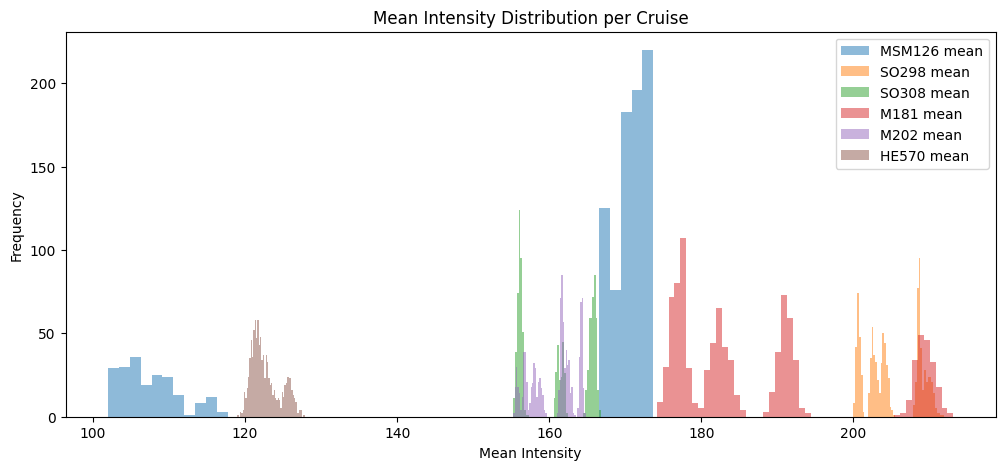

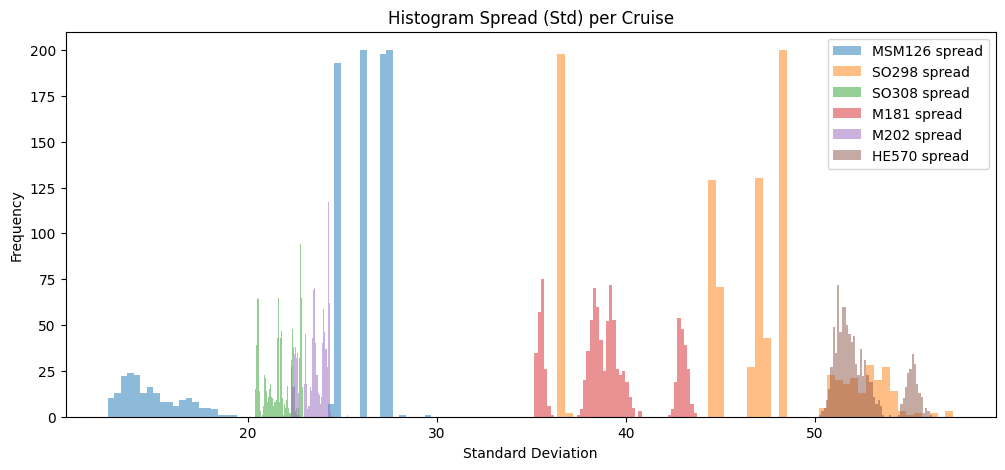

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from glob import glob

def analyze_intensity_and_histogram_spread(dataset_dir, image_ext=".png"):
    cruise_stats = {}
    cruises = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
    for cruise in cruises:
        cruise_path = os.path.join(dataset_dir, cruise)
        images = glob(os.path.join(cruise_path, f"*{image_ext}"))
        means = []
        spreads = []
        for img_path in images:
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            arr = np.array(img)
            means.append(arr.mean())
            spreads.append(arr.std())  # Histogram spread as standard deviation
        cruise_stats[cruise] = {
            "means": means,
            "spreads": spreads
        }
        print(f"{cruise}: {len(means)} images analyzed.")
    
    # Plot mean intensity
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["means"], bins=50, alpha=0.5, label=f"{cruise} mean")
    plt.title("Mean Intensity Distribution per Cruise")
    plt.xlabel("Mean Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
    # Plot histogram spread
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["spreads"], bins=50, alpha=0.5, label=f"{cruise} spread")
    plt.title("Histogram Spread (Std) per Cruise")
    plt.xlabel("Standard Deviation")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Example usage:
analyze_intensity_and_histogram_spread("/home/veit/Documents/PIScO_benchmark_dataset")

Perform the segmentation here. Seperate script runs faster when directly run from terminal. (pisco) veit@piscodisco:~/PIScO_dev/ImageProcessing$ python segment_benchmark_dataset.py


MSM126: 1501 bg-corrected images analyzed.
SO298: 5123 bg-corrected images analyzed.
SO308: 23836 bg-corrected images analyzed.
M181: 2542 bg-corrected images analyzed.
blurred: 2282 bg-corrected images analyzed.
M202: 938 bg-corrected images analyzed.
HE570: 2144 bg-corrected images analyzed.
results: 0 bg-corrected images analyzed.


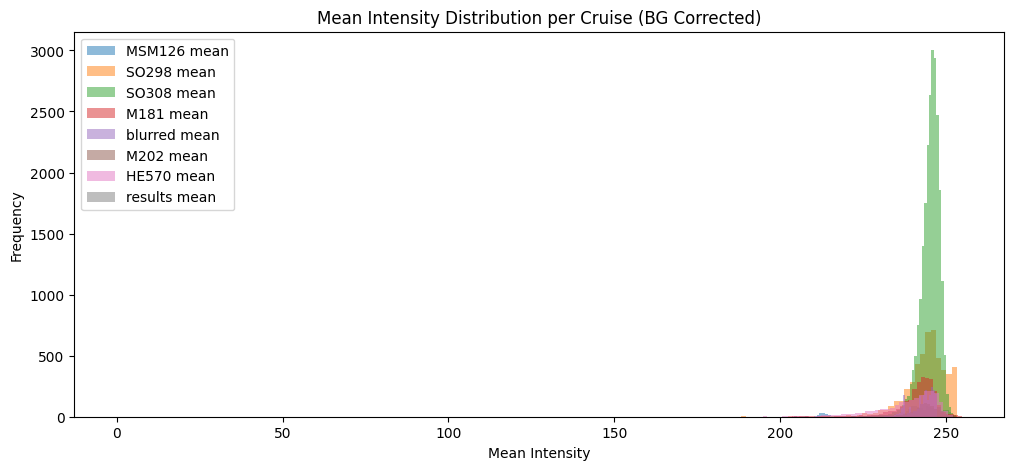

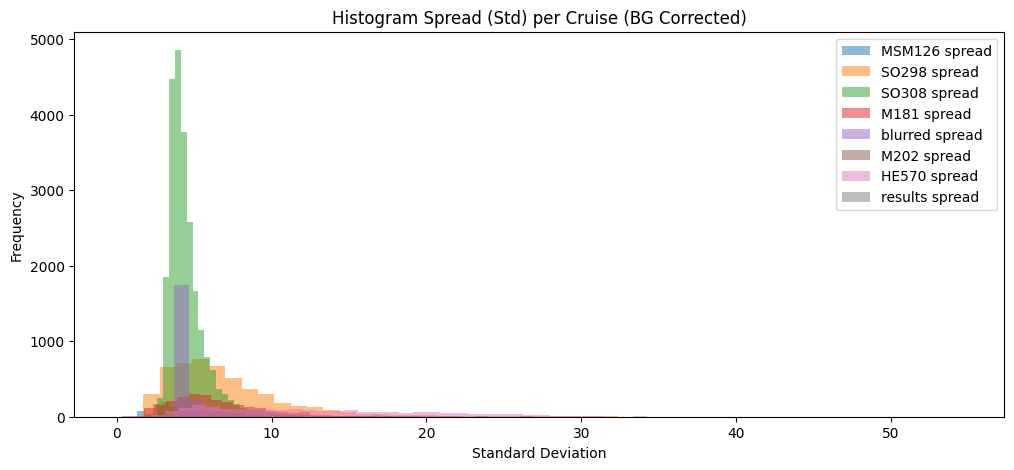

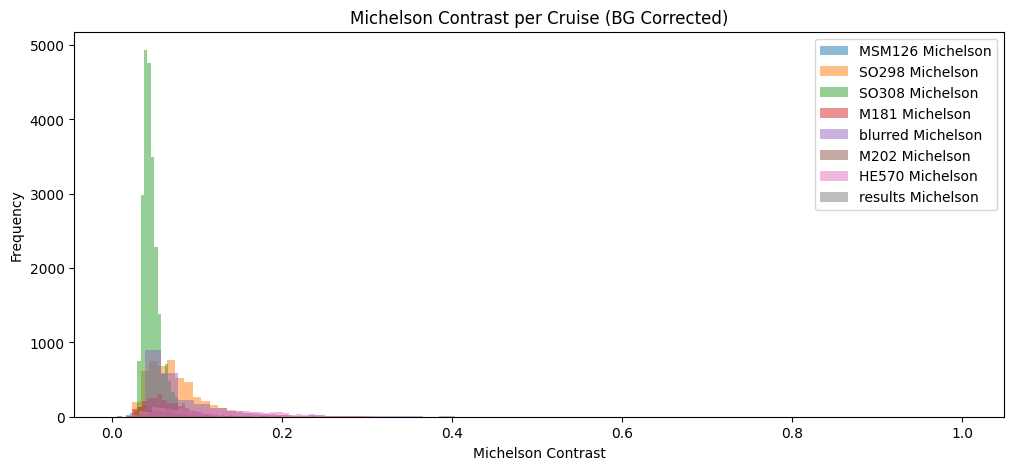

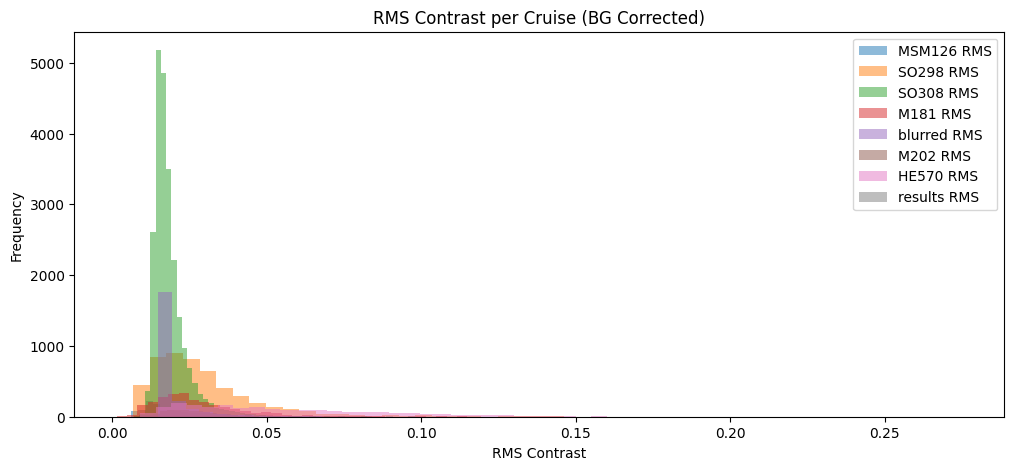

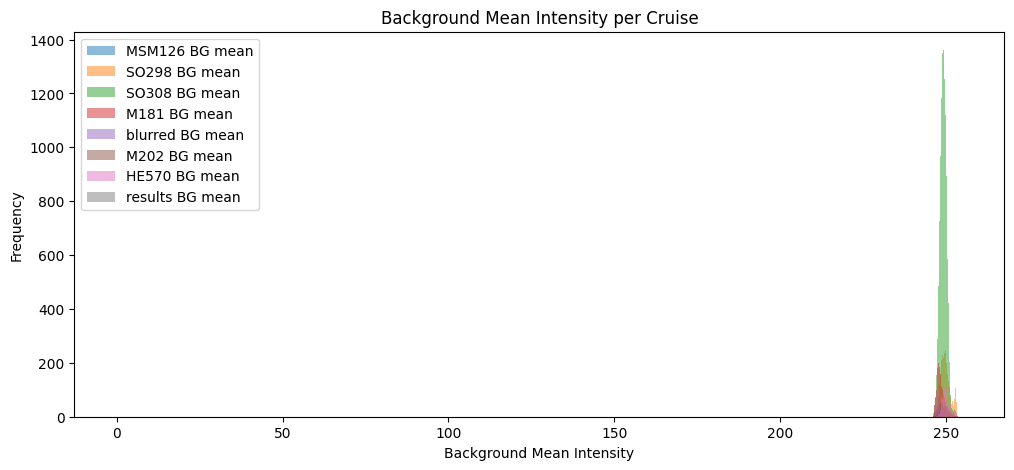

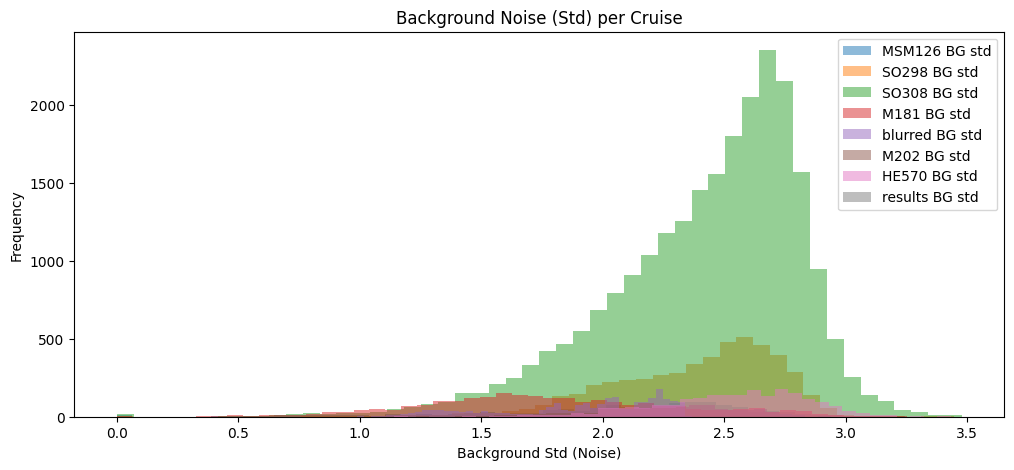

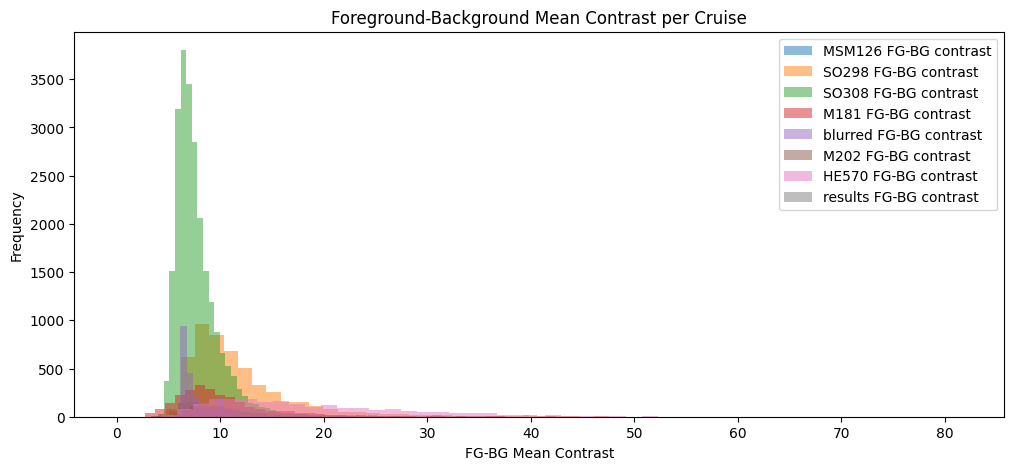

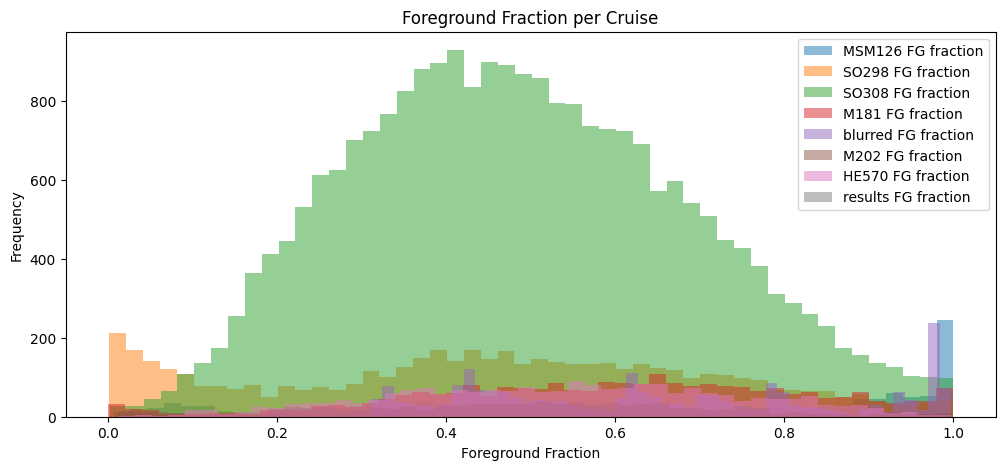

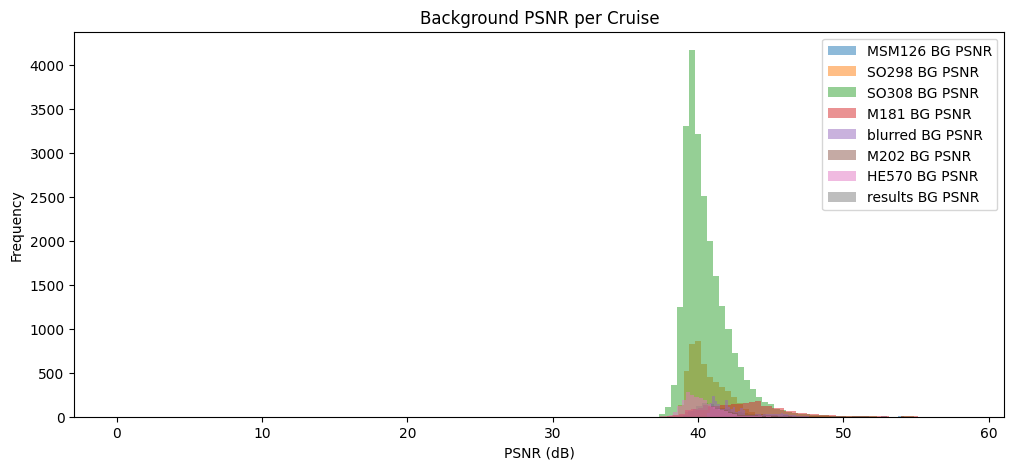

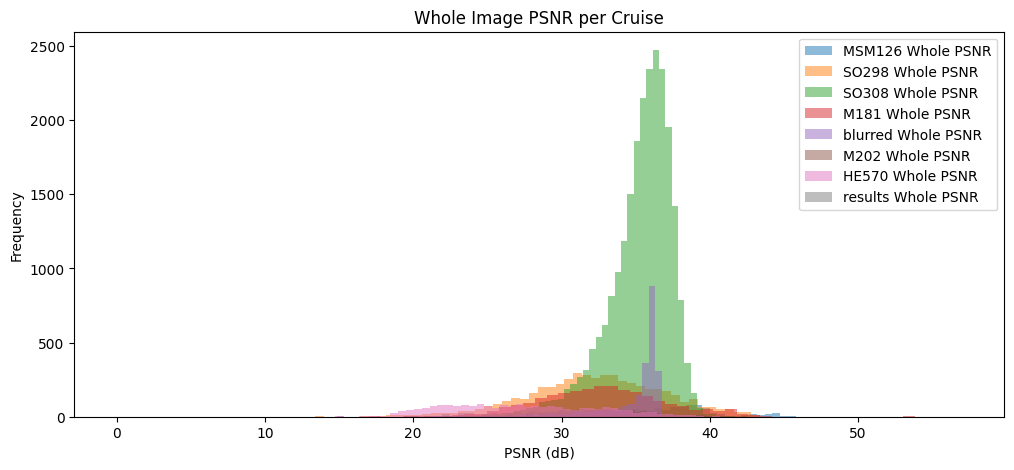

In [19]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from glob import glob

def michelson_contrast(arr):
    I_max = int(arr.max())
    I_min = int(arr.min())
    if I_max + I_min == 0:
        return 0
    return (I_max - I_min) / (I_max + I_min)

def rms_contrast(arr):
    mean = arr.mean()
    if mean == 0:
        return 0
    return arr.std() / mean

def psnr_from_std(bg_std, max_i=255.0):
    # Avoid division by zero or nan
    if np.isnan(bg_std) or bg_std == 0:
        return np.nan
    mse = bg_std ** 2
    return 20 * np.log10(max_i / np.sqrt(mse))

def get_bg_fg_stats(arr, threshold=200):
    mask_bg = arr > threshold
    mask_fg = arr <= threshold
    bg_mean = arr[mask_bg].mean() if np.any(mask_bg) else np.nan
    bg_std = arr[mask_bg].std() if np.any(mask_bg) else np.nan
    fg_mean = arr[mask_fg].mean() if np.any(mask_fg) else np.nan
    fg_std = arr[mask_fg].std() if np.any(mask_fg) else np.nan
    fg_frac = np.sum(mask_fg) / arr.size
    fg_bg_contrast = abs(bg_mean - fg_mean) if not (np.isnan(bg_mean) or np.isnan(fg_mean)) else np.nan
    return bg_mean, bg_std, fg_mean, fg_std, fg_bg_contrast, fg_frac

def psnr_from_std(std, max_i=255.0):
    if np.isnan(std) or std == 0:
        return np.nan
    mse = std ** 2
    return 20 * np.log10(max_i / np.sqrt(mse))

def analyze_bg_corrected_intensity_and_spread(dataset_dir, image_ext=".png", threshold=245):
    cruise_stats = {}
    cruises = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
    for cruise in cruises:
        images_path = os.path.join(dataset_dir, cruise, "Crops")
        images = glob(os.path.join(images_path, f"*{image_ext}"))

        means = []
        spreads = []
        michelsons = []
        rms_contrasts = []
        bg_means = []
        bg_stds = []
        fg_means = []
        fg_stds = []
        fg_bg_contrasts = []
        fg_fracs = []
        psnrs = []
        psnrs_whole = []
        for img_path in images:
            img = Image.open(img_path).convert("L")
            arr = np.array(img)
            means.append(arr.mean())
            std = arr.std()
            spreads.append(std)
            michelsons.append(michelson_contrast(arr))
            rms_contrasts.append(rms_contrast(arr))
            bg_mean, bg_std, fg_mean, fg_std, fg_bg_contrast, fg_frac = get_bg_fg_stats(arr, threshold)
            bg_means.append(bg_mean)
            bg_stds.append(bg_std)
            fg_means.append(fg_mean)
            fg_stds.append(fg_std)
            fg_bg_contrasts.append(fg_bg_contrast)
            fg_fracs.append(fg_frac)
            psnrs.append(psnr_from_std(bg_std))
            psnrs_whole.append(psnr_from_std(std))
        cruise_stats[cruise] = {
            "means": means,
            "spreads": spreads,
            "michelson": michelsons,
            "rms": rms_contrasts,
            "bg_means": bg_means,
            "bg_stds": bg_stds,
            "fg_means": fg_means,
            "fg_stds": fg_stds,
            "fg_bg_contrasts": fg_bg_contrasts,
            "fg_fracs": fg_fracs,
            "psnr": psnrs,
            "psnr_whole": psnrs_whole
        }
        print(f"{cruise}: {len(means)} bg-corrected images analyzed.")
    
    # Plot mean intensity
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["means"], bins=50, alpha=0.5, label=f"{cruise} mean")
    plt.title("Mean Intensity Distribution per Cruise (BG Corrected)")
    plt.xlabel("Mean Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
    # Plot histogram spread
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["spreads"], bins=50, alpha=0.5, label=f"{cruise} spread")
    plt.title("Histogram Spread (Std) per Cruise (BG Corrected)")
    plt.xlabel("Standard Deviation")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # Calculate x-limits for Michelson and RMS contrast
    all_michelson = np.concatenate([stats["michelson"] for stats in cruise_stats.values()])
    all_rms = np.concatenate([stats["rms"] for stats in cruise_stats.values()])
    michelson_min, michelson_max = all_michelson.min(), all_michelson.max()
    rms_min, rms_max = all_rms.min(), all_rms.max()
    michelson_margin = (michelson_max - michelson_min) * 0.05
    rms_margin = (rms_max - rms_min) * 0.05

    # Plot Michelson contrast
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["michelson"], bins=50, alpha=0.5, label=f"{cruise} Michelson")
    plt.title("Michelson Contrast per Cruise (BG Corrected)")
    plt.xlabel("Michelson Contrast")
    plt.ylabel("Frequency")
    plt.xlim(michelson_min - michelson_margin, michelson_max + michelson_margin)
    plt.legend()
    plt.show()

    # Plot RMS contrast
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["rms"], bins=50, alpha=0.5, label=f"{cruise} RMS")
    plt.title("RMS Contrast per Cruise (BG Corrected)")
    plt.xlabel("RMS Contrast")
    plt.ylabel("Frequency")
    plt.xlim(rms_min - rms_margin, rms_max + rms_margin)
    plt.legend()
    plt.show()

    # Plot background mean
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["bg_means"], bins=50, alpha=0.5, label=f"{cruise} BG mean")
    plt.title("Background Mean Intensity per Cruise")
    plt.xlabel("Background Mean Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # Plot background std (noise)
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["bg_stds"], bins=50, alpha=0.5, label=f"{cruise} BG std")
    plt.title("Background Noise (Std) per Cruise")
    plt.xlabel("Background Std (Noise)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # Plot foreground-background contrast
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["fg_bg_contrasts"], bins=50, alpha=0.5, label=f"{cruise} FG-BG contrast")
    plt.title("Foreground-Background Mean Contrast per Cruise")
    plt.xlabel("FG-BG Mean Contrast")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # Plot foreground fraction
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["fg_fracs"], bins=50, alpha=0.5, label=f"{cruise} FG fraction")
    plt.title("Foreground Fraction per Cruise")
    plt.xlabel("Foreground Fraction")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

        # Plot PSNR (background)
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["psnr"], bins=50, alpha=0.5, label=f"{cruise} BG PSNR")
    plt.title("Background PSNR per Cruise")
    plt.xlabel("PSNR (dB)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # Plot PSNR (whole image)
    plt.figure(figsize=(12, 5))
    for cruise, stats in cruise_stats.items():
        plt.hist(stats["psnr_whole"], bins=50, alpha=0.5, label=f"{cruise} Whole PSNR")
    plt.title("Whole Image PSNR per Cruise")
    plt.xlabel("PSNR (dB)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Example usage:
analyze_bg_corrected_intensity_and_spread("/home/veit/Documents/PIScO_benchmark_dataset")

In [21]:
import os
import pandas as pd
import analyze_profiles_seavision as ap
from datasets import Dataset, Features, Image as ImageFeature, Value, concatenate_datasets
import glob


results_folder = "/home/veit/Documents/PIScO_benchmark_dataset/results"
os.makedirs(results_folder, exist_ok=True)

all_predictions = []

benchmark_dir = "/home/veit/Documents/PIScO_benchmark_dataset"
cruises = [d for d in os.listdir(benchmark_dir) if os.path.isdir(os.path.join(benchmark_dir, d))]

for cruise in cruises:
    results_folders = glob.glob(os.path.join("/home/veit/Documents/PIScO_benchmark_dataset", cruise, "results_*"))
    if results_folders:
        results_folder = sorted(results_folders)[-1]  # or [0] for the first
    img_dir = os.path.join(benchmark_dir, cruise, results_folder, "Deconv_crops")
    if not os.path.isdir(img_dir):
        continue
    valid_filenames = [f for f in os.listdir(img_dir) if f.endswith(".png")]
    valid_filenames = [os.path.join(img_dir, f) for f in valid_filenames]

    ds_pisco = ap.load_unclassified_images(img_dir)
    ds_pisco_trans = ds_pisco.with_transform(ap.process_batch)
    print(f"Processing cruise: {cruise}, {len(valid_filenames)} images found.")
    print(f"Valid filenames: {len(valid_filenames)}")
    print(f"First 5 filenames: {valid_filenames[:5]}")
    print(f"Dataset length: {len(ds_pisco)}")
    print(f"Transformed dataset length: {len(ds_pisco_trans)}")

    # Binary classifier
    model_dir_bin = '/home/veit/PIScO_dev/ViT_custom_size_sensitive_binary/best_model'
    filenames, predictions, probabilities, entropy_scores, ood_flags = ap.get_predictions_with_entropy_ood_binary(
        ds_pisco_trans, 
        model_dir_bin, 
        entropy_threshold=0.5,
        temperature=1.5,
        batch_size=64
    )
    prediction_df = pd.DataFrame({
        'filename': filenames,
        'is_ood': ood_flags,
        'entropy': entropy_scores,
        'top1': [pred[0] for pred in predictions],
        'prob1': [prob[0] for prob in probabilities],
        'cruise': cruise
    })

    # Filter for living
    living_filenames = prediction_df[prediction_df['top1'] == 'living']['filename'].tolist()
    living_data = {'image': living_filenames, 'label': living_filenames}
    features = Features({'image': ImageFeature(), 'label': Value('string')})
    ds_living = Dataset.from_dict(living_data, features=features)
    ds_living_trans = ds_living.with_transform(ap.process_batch)

    # Multiclass classifier
    model_dir_multi = '/home/veit/PIScO_dev/ViT_custom_size_sensitive_v4/best_model'
    filenames_living, predictions_living, probabilities_living, entropy_scores_living, ood_flags_living = ap.get_predictions_with_entropy_ood(
        ds_living_trans, 
        model_dir_multi, 
        entropy_threshold=0.9,
        temperature=1.5,
        batch_size=64
    )
    df_living = pd.DataFrame({
        'filename': filenames_living,
        'is_ood': ood_flags_living,
        'entropy': entropy_scores_living,
        'top1': [pred[0] for pred in predictions_living],
        'top2': [pred[1] for pred in predictions_living],
        'top3': [pred[2] for pred in predictions_living],
        'top4': [pred[3] for pred in predictions_living],
        'top5': [pred[4] for pred in predictions_living],
        'prob1': [prob[0] for prob in probabilities_living],
        'prob2': [prob[1] for prob in probabilities_living],
        'prob3': [prob[2] for prob in probabilities_living],
        'prob4': [prob[3] for prob in probabilities_living],
        'prob5': [prob[4] for prob in probabilities_living],
        'cruise': cruise
    })

    # Merge multiclass into binary
    df_living = df_living.set_index('filename')
    prediction_df = prediction_df.set_index('filename')
    for col in ['top1', 'top2', 'top3', 'top4', 'top5', 'prob1', 'prob2', 'prob3', 'prob4', 'prob5', 'entropy', 'is_ood']:
        prediction_df.loc[df_living.index, col] = df_living[col]
    prediction_df = prediction_df.reset_index()
    prediction_df['filename'] = prediction_df['filename'].apply(os.path.basename)
    all_predictions.append(prediction_df)

# Combine all cruises and save
prediction_df_all = pd.concat(all_predictions, ignore_index=True)
result_path = os.path.join(results_folder, 'ViT_predictions2.csv')
prediction_df_all.to_csv(result_path, index=False)
print("Predictions saved for all cruises!")

Processing cruise: MSM126, 3847 images found.
Valid filenames: 3847
First 5 filenames: ['/home/veit/Documents/PIScO_benchmark_dataset/MSM126/results_20250717_153814/Deconv_crops/MSM126_046-01_PISCO2_20240220-1856_MSM126_046-01_PISCO2_0009.74dbar-32.63N-017.09W-23.66C_20240220-19001059_112.png', '/home/veit/Documents/PIScO_benchmark_dataset/MSM126/results_20250717_153814/Deconv_crops/MSM126_046-01_PISCO2_20240220-1856_MSM126_046-01_PISCO2_0009.74dbar-32.63N-017.09W-23.67C_20240220-18595389_708.png', '/home/veit/Documents/PIScO_benchmark_dataset/MSM126/results_20250717_153814/Deconv_crops/MSM126_046-01_PISCO2_20240220-1856_MSM126_046-01_PISCO2_0009.74dbar-32.63N-017.09W-23.66C_20240220-19000939_131.png', '/home/veit/Documents/PIScO_benchmark_dataset/MSM126/results_20250717_153814/Deconv_crops/MSM126_046-01_PISCO2_20240220-1856_MSM126_046-01_PISCO2_0009.74dbar-32.63N-017.09W-23.66C_20240220-19001059_686.png', '/home/veit/Documents/PIScO_benchmark_dataset/MSM126/results_20250717_153814/Dec

Processing dataset:   0%|          | 0/61 [00:00<?, ?it/s]2025-07-17 16:12:34,413 - Skipping: <PIL.Image.Image image mode=RGB size=2560x9 at 0x7A3ED8258230>: image size: (2560, 9), new height: 0, new width: 224
2025-07-17 16:12:34,640 - Skipping: <PIL.Image.Image image mode=RGB size=2560x4 at 0x7A3B060E8080>: image size: (2560, 4), new height: 0, new width: 224
/home/veit/miniconda3/envs/pisco/lib/python3.12/site-packages/transformers/integrations/sdpa_attention.py:54: UserWarning: Using AOTriton backend for Flash Attention forward... (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/flash_attn/flash_api.h:267.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Processing dataset:  18%|█▊        | 11/61 [00:01<00:03, 14.26it/s]2025-07-17 16:12:35,466 - Skipping: <PIL.Image.Image image mode=RGB size=2560x5 at 0x7A3B059CABA0>: image size: (2560, 5), new height: 0, new width: 224
2025-07-17 16:12:35,550 - Skipping: <PIL.Image.Image image mode=RGB size

Initializing model for predictions
Using device: cuda


Processing dataset:   0%|          | 0/4 [00:00<?, ?it/s]2025-07-17 16:12:38,946 - Skipping: <PIL.Image.Image image mode=RGB size=2560x5 at 0x7A3B05924A70>: image size: (2560, 5), new height: 0, new width: 224
2025-07-17 16:12:39,054 - Skipping: <PIL.Image.Image image mode=RGB size=2560x4 at 0x7A3F51E2F9E0>: image size: (2560, 4), new height: 0, new width: 224
Processing dataset: 100%|██████████| 4/4 [00:00<00:00,  7.42it/s]


Processing cruise: SO298, 6342 images found.
Valid filenames: 6342
First 5 filenames: ['/home/veit/Documents/PIScO_benchmark_dataset/SO298/results_20250717_154505/Deconv_crops/SO298_298-22-1_PISCO2_20230506-2140_SO298_298-22-1_PISCO2_0305.99dbar-00.00S-141.75W-15.29C_20230506-21510891_34.png', '/home/veit/Documents/PIScO_benchmark_dataset/SO298/results_20250717_154505/Deconv_crops/SO298_298-38-1_PISCO2_20230525-1853_SO298_298-38-1_PISCO2_0117.18dbar-00.00S-160.00E-30.02C_20230525-19051622_5.png', '/home/veit/Documents/PIScO_benchmark_dataset/SO298/results_20250717_154505/Deconv_crops/SO298_298-37-3_PISCO2_20230524-1954_SO298_298-37-3_PISCO2_0674.88dbar-00.00S-163.50E-06.89C_20230524-21310620_5.png', '/home/veit/Documents/PIScO_benchmark_dataset/SO298/results_20250717_154505/Deconv_crops/SO298_298-38-1_PISCO2_20230525-1853_SO298_298-38-1_PISCO2_0102.06dbar-00.00S-160.00E-29.99C_20230525-19050032_70.png', '/home/veit/Documents/PIScO_benchmark_dataset/SO298/results_20250717_154505/Deconv_

...

Processing cruise: results, 0 images found.
Valid filenames: 0
First 5 filenames: []
Dataset length: 0
Transformed dataset length: 0
Initializing model for predictions
Using device: cuda


Processing dataset: 0it [00:00, ?it/s]


Initializing model for predictions
Using device: cuda


Processing dataset: 0it [00:00, ?it/s]
/tmp/ipykernel_1556183/953579884.py:95: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prediction_df_all = pd.concat(all_predictions, ignore_index=True)


Predictions saved for all cruises!


/tmp/ipykernel_1556183/2225279304.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)


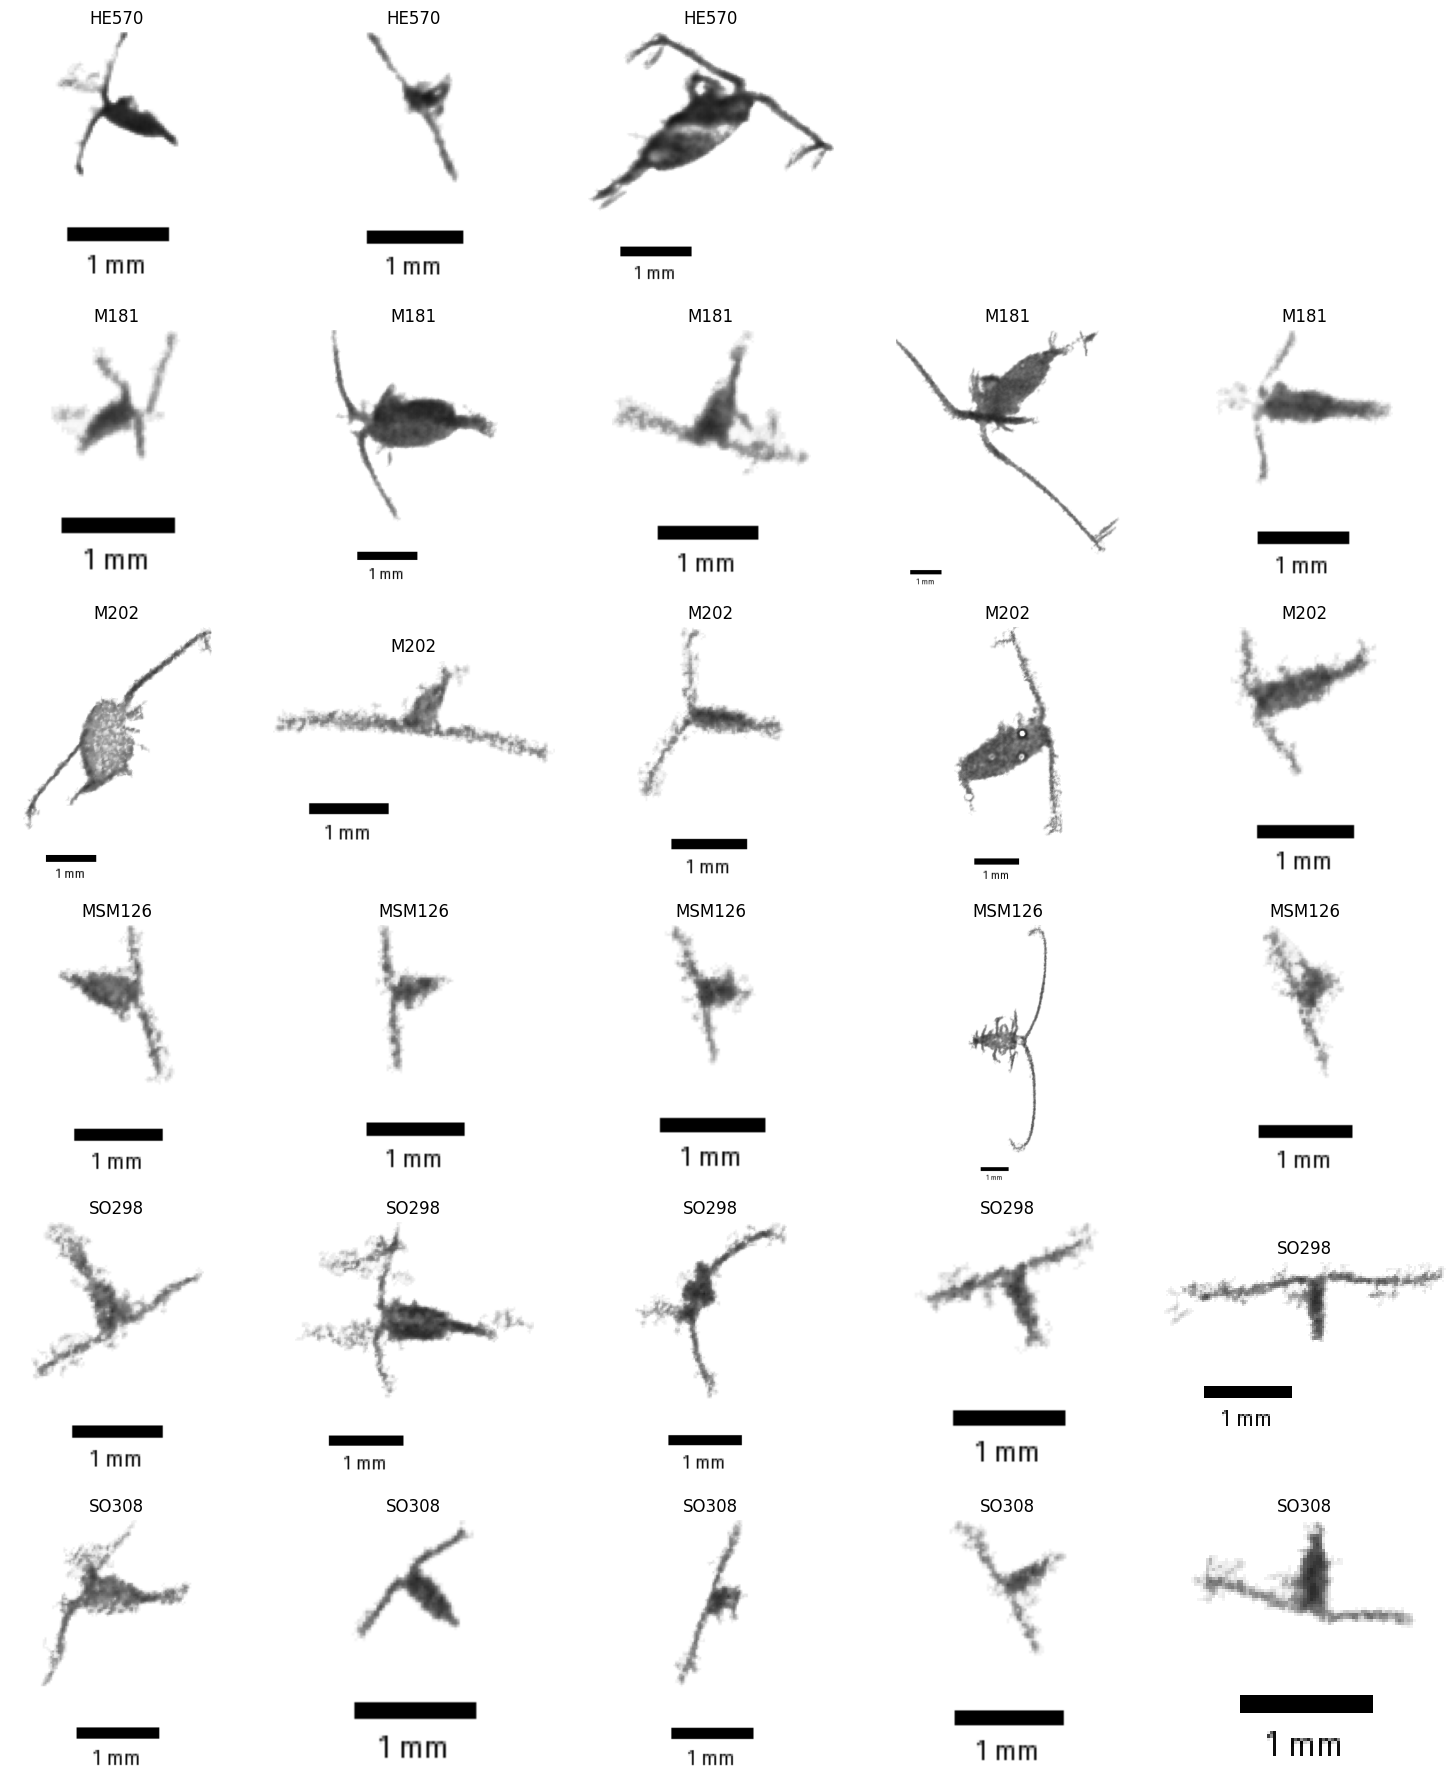

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import os

def add_scale_bar_to_pil(img, pixel_resolution=23, scale_length_mm=1):
    """
    Adds a scale bar below the PIL image and returns a new PIL image.
    """
    scale_length_px = int((scale_length_mm * 1000) / pixel_resolution)
    extra_height = 50
    bar_height = 5
    margin = 20

    min_width = scale_length_px + 2 * margin
    pad_left = pad_right = 0
    if img.width < min_width:
        pad_total = min_width - img.width
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        padded_img = Image.new("RGB", (min_width, img.height), "white")
        padded_img.paste(img.convert("RGB"), (pad_left, 0))
        img = padded_img

    new_img = Image.new("RGB", (img.width, img.height + extra_height), "white")
    new_img.paste(img, (0, 0))
    draw = ImageDraw.Draw(new_img)

    bar_x_start = margin
    bar_x_end = bar_x_start + scale_length_px
    bar_y_start = img.height + (extra_height - bar_height) // 2
    bar_y_end = bar_y_start + bar_height

    draw.rectangle([bar_x_start, bar_y_start, bar_x_end, bar_y_end], fill="black")

    text = f"{scale_length_mm} mm"
    font_size = 20
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()
    text_bbox = font.getbbox(text)
    text_width = text_bbox[2] - text_bbox[0]
    text_x = bar_x_start + (scale_length_px - text_width) // 2
    text_y = bar_y_end + 5
    draw.text((text_x, text_y), text, fill="black", font=font)

    return new_img

# --- Your plotting code with scale bar added ---

pred_path = "/home/veit/Documents/results/ViT_predictions.csv"
df = pd.read_csv(pred_path)
df_calanoida = df[df['top1'] == 'Calanoida']
sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)

cruises = sampled['cruise'].unique()
n_cruises = len(cruises)
n_cols = 5

fig, axes = plt.subplots(n_cruises, n_cols, figsize=(3 * n_cols, 3 * n_cruises), squeeze=False)

for i, cruise in enumerate(cruises):
    cruise_samples = sampled[sampled['cruise'] == cruise].reset_index(drop=True)
    for j in range(n_cols):
        ax = axes[i, j]
        if j < len(cruise_samples):
            row = cruise_samples.iloc[j]
            img_path = os.path.join("/home/veit/Documents/PIScO_benchmark_dataset", cruise, "Deconv_crops", row['filename'])
            if os.path.exists(img_path):
                img = Image.open(img_path)
                img_with_bar = add_scale_bar_to_pil(img, pixel_resolution=23, scale_length_mm=1)
                ax.imshow(img_with_bar)
                ax.set_title(f"{cruise}")
            else:
                print(f"Image not found: {img_path}")
                ax.set_facecolor('black')
            ax.axis('off')
        else:
            ax.axis('off')
    axes[i, 0].set_ylabel(cruise, rotation=0, size='large', labelpad=40, va='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1556183/2339688674.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)


Processing image: /home/veit/Documents/PIScO_benchmark_dataset/HE570/Crops/20210305_HE570_027-bop-005_PISCO1_HE570_027_PISCO1_141.55dbar-60.88lat-005.50lon_20210305_072649.090_37.png
Processing image: /home/veit/Documents/PIScO_benchmark_dataset/HE570/Crops/20210307_HE570_069-bop-015b_PISCO1_HE570_069_PISCO1_266.16dbar-60.87lat-005.41lon_20210307_034823.260_155.png
Processing image: /home/veit/Documents/PIScO_benchmark_dataset/HE570/Crops/20210315_HE570_215-bop-038b_PISCO1_HE570_215_PISCO1_281.21dbar-60.69lat-005.15lon_20210315_170951.890_50.png
Processing image: /home/veit/Documents/PIScO_benchmark_dataset/M181/Crops/M181-281-1_CTD-073_00°00S-038°00W_20220517-0828_20220517-08521316_001.934bar_28.66C_52.png
Processing image: /home/veit/Documents/PIScO_benchmark_dataset/M181/Crops/M181-281-1_CTD-073_00°00S-038°00W_20220517-0828_20220517-08514516_001.580bar_28.69C_92.png
Processing image: /home/veit/Documents/PIScO_benchmark_dataset/M181/Crops/M181-288-1_CTD-077_00°00S-040°00W_20220518-0

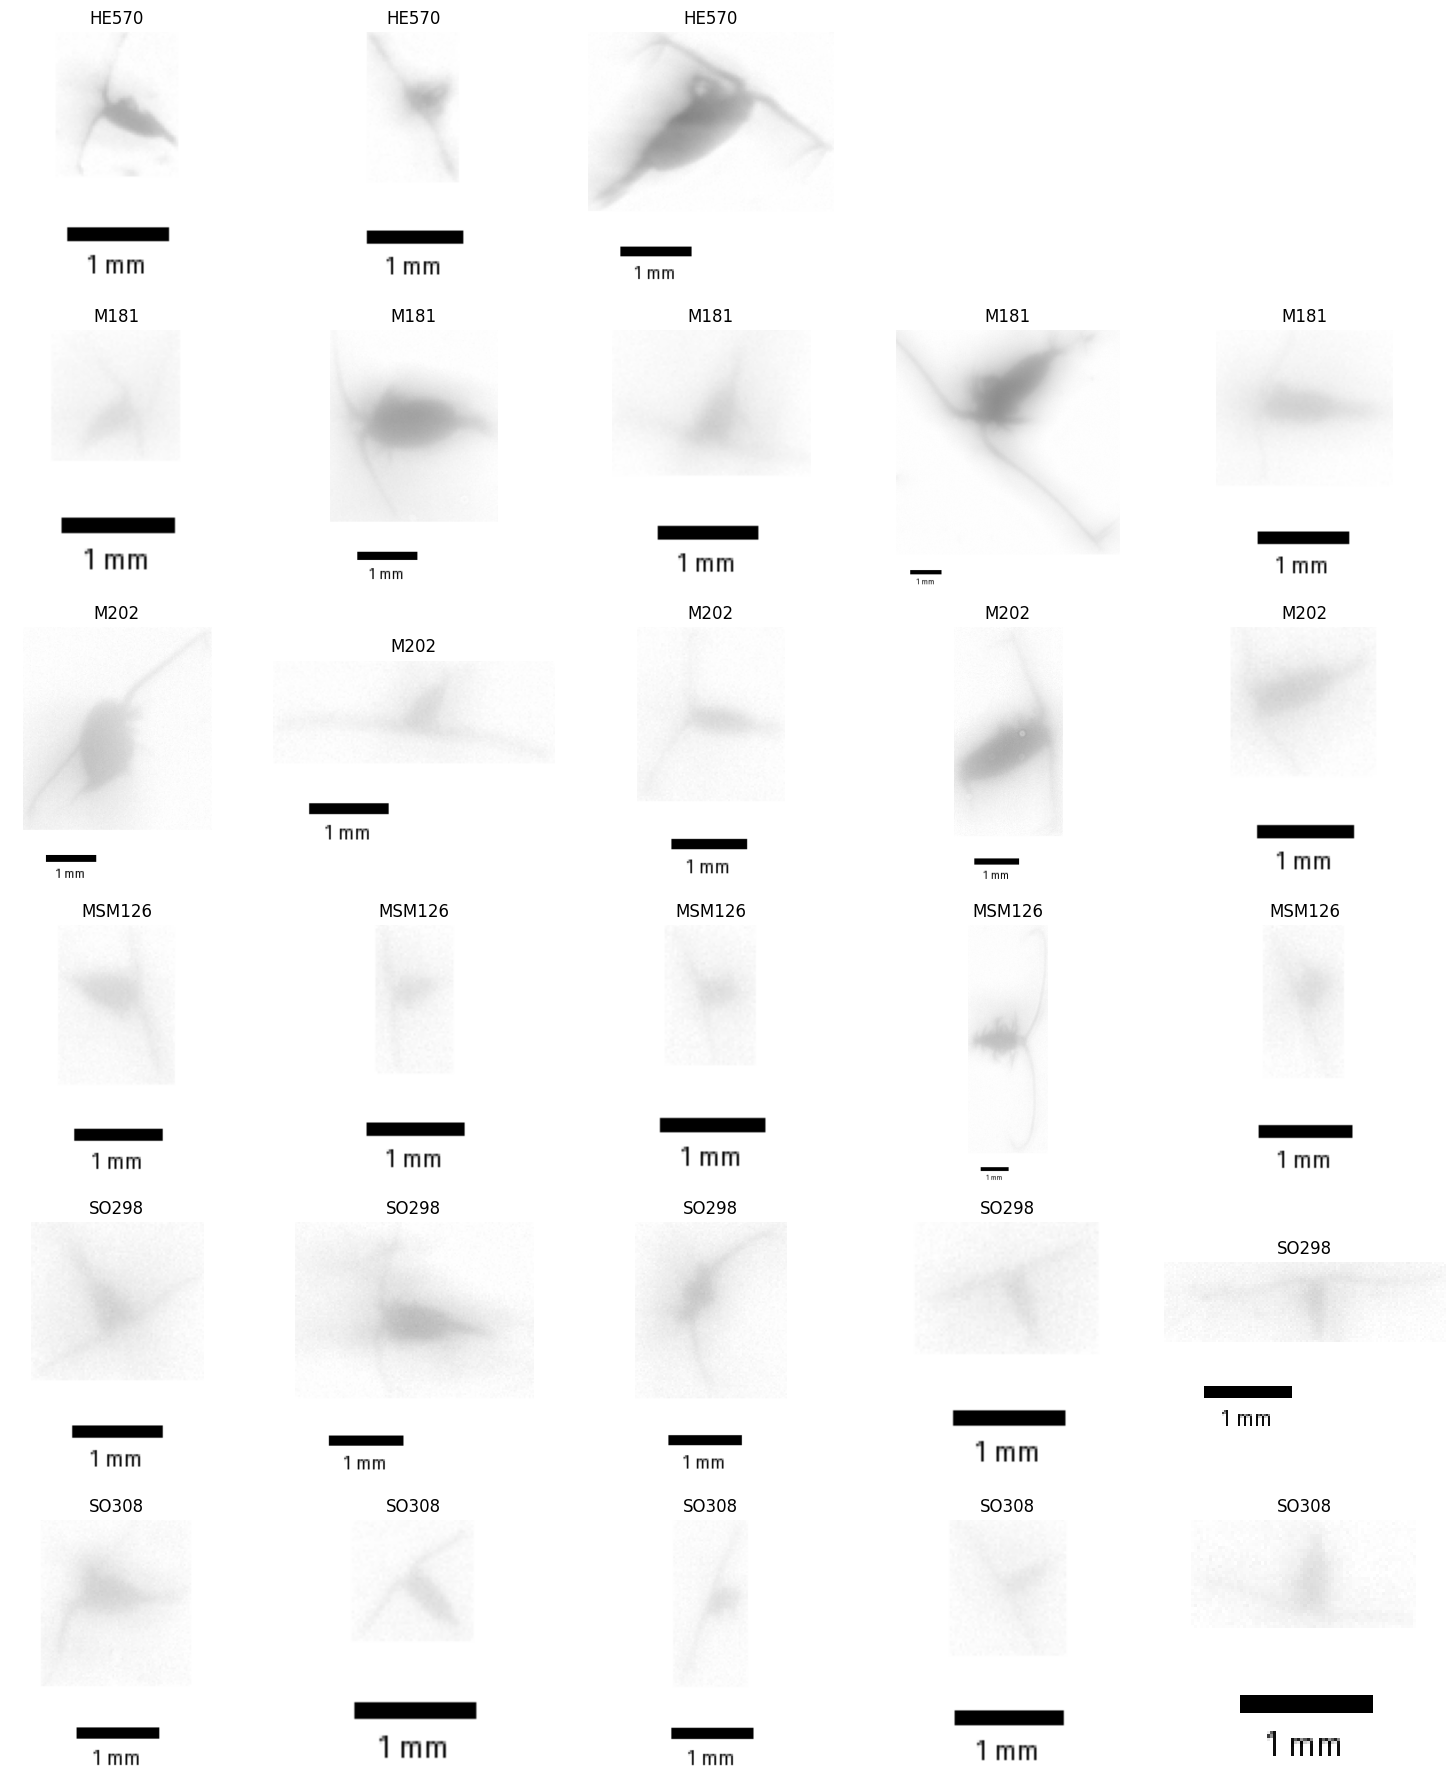

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import os

def add_scale_bar_to_pil(img, pixel_resolution=23, scale_length_mm=1):
    """
    Adds a scale bar below the PIL image and returns a new PIL image.
    """
    scale_length_px = int((scale_length_mm * 1000) / pixel_resolution)
    extra_height = 50
    bar_height = 5
    margin = 20

    min_width = scale_length_px + 2 * margin
    pad_left = pad_right = 0
    if img.width < min_width:
        pad_total = min_width - img.width
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        padded_img = Image.new("RGB", (min_width, img.height), "white")
        padded_img.paste(img.convert("RGB"), (pad_left, 0))
        img = padded_img

    new_img = Image.new("RGB", (img.width, img.height + extra_height), "white")
    new_img.paste(img, (0, 0))
    draw = ImageDraw.Draw(new_img)

    bar_x_start = margin
    bar_x_end = bar_x_start + scale_length_px
    bar_y_start = img.height + (extra_height - bar_height) // 2
    bar_y_end = bar_y_start + bar_height

    draw.rectangle([bar_x_start, bar_y_start, bar_x_end, bar_y_end], fill="black")

    text = f"{scale_length_mm} mm"
    font_size = 20
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()
    text_bbox = font.getbbox(text)
    text_width = text_bbox[2] - text_bbox[0]
    text_x = bar_x_start + (scale_length_px - text_width) // 2
    text_y = bar_y_end + 5
    draw.text((text_x, text_y), text, fill="black", font=font)

    return new_img

# --- Your plotting code with scale bar added ---

pred_path = "/home/veit/Documents/results/ViT_predictions.csv"
df = pd.read_csv(pred_path)
df_calanoida = df[df['top1'] == 'Calanoida']
sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)

cruises = sampled['cruise'].unique()
n_cruises = len(cruises)
n_cols = 5

fig, axes = plt.subplots(n_cruises, n_cols, figsize=(3 * n_cols, 3 * n_cruises), squeeze=False)

for i, cruise in enumerate(cruises):
    cruise_samples = sampled[sampled['cruise'] == cruise].reset_index(drop=True)
    for j in range(n_cols):
        ax = axes[i, j]
        if j < len(cruise_samples):
            row = cruise_samples.iloc[j]
            img_path = os.path.join("/home/veit/Documents/PIScO_benchmark_dataset", cruise, "Crops", row['filename'])
            print(f"Processing image: {img_path}")
            if os.path.exists(img_path):
                img = Image.open(img_path)
                img_with_bar = add_scale_bar_to_pil(img, pixel_resolution=23, scale_length_mm=1)
                ax.imshow(img_with_bar)
                ax.set_title(f"{cruise}")
            else:
                ax.set_facecolor('black')
            ax.axis('off')
        else:
            ax.axis('off')
    axes[i, 0].set_ylabel(cruise, rotation=0, size='large', labelpad=40, va='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1556183/3017404555.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)


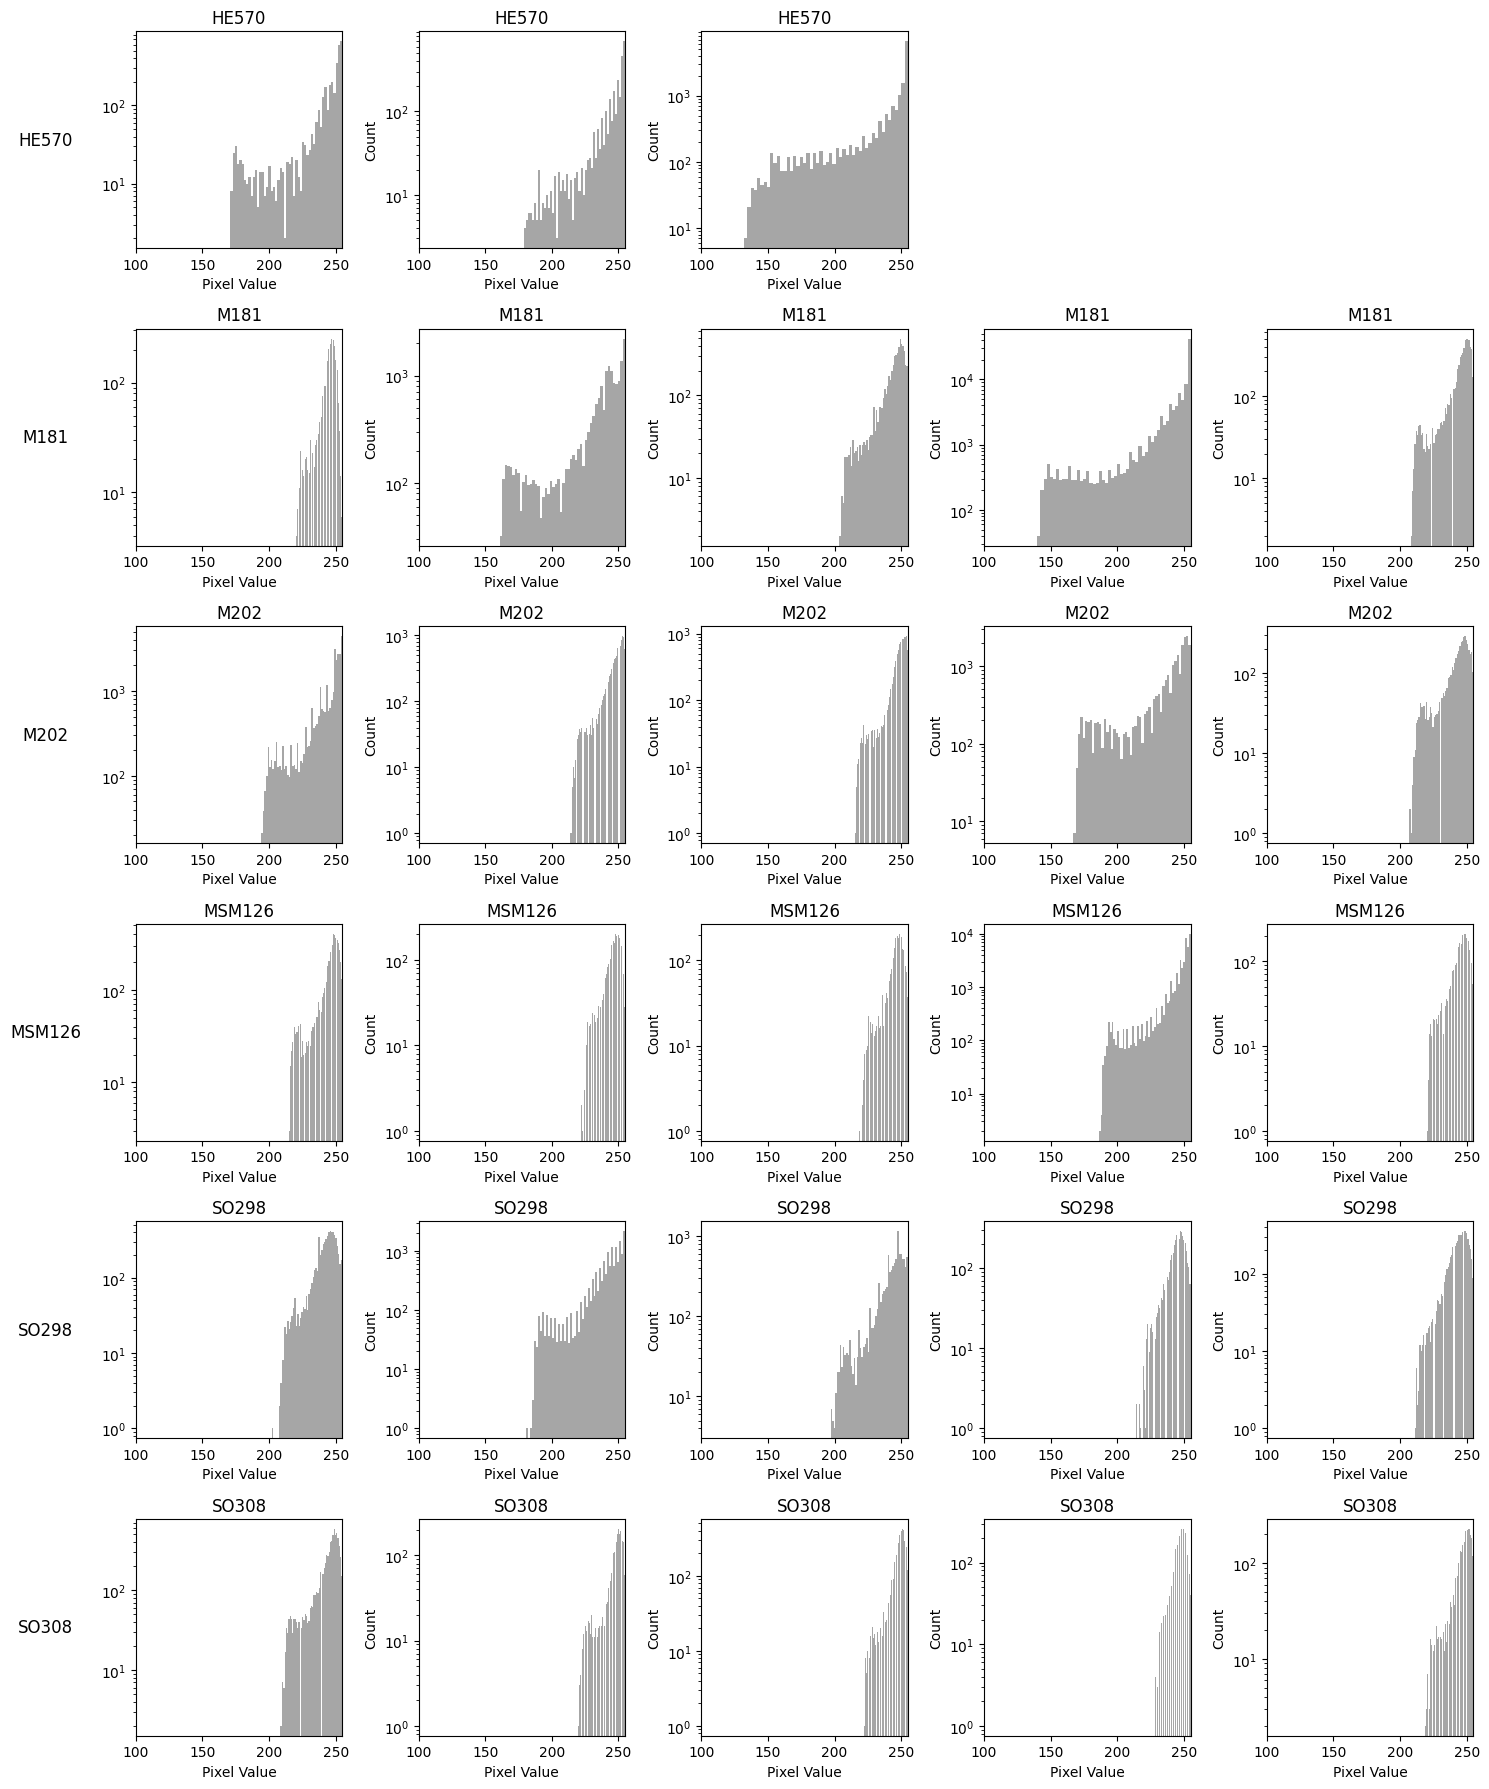

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

pred_path = "/home/veit/Documents/results/ViT_predictions.csv"
df = pd.read_csv(pred_path)
df_calanoida = df[df['top1'] == 'Calanoida']
sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)

cruises = sampled['cruise'].unique()
n_cruises = len(cruises)
n_cols = 5

fig, axes = plt.subplots(n_cruises, n_cols, figsize=(3 * n_cols, 3 * n_cruises), squeeze=False)

for i, cruise in enumerate(cruises):
    cruise_samples = sampled[sampled['cruise'] == cruise].reset_index(drop=True)
    for j in range(n_cols):
        ax = axes[i, j]
        if j < len(cruise_samples):
            row = cruise_samples.iloc[j]
            img_path = os.path.join("/home/veit/Documents/PIScO_benchmark_dataset", cruise, "Crops", row['filename'])
            if os.path.exists(img_path):
                img = Image.open(img_path).convert("L")
                arr = np.array(img)
                ax.hist(arr.flatten(), bins=50, color='gray', alpha=0.7)
                ax.set_yscale('log')  # Set y-axis to log scale
                ax.set_title(f"{cruise}")
                ax.set_xlim(100, 255)
                ax.set_xlabel("Pixel Value")
                ax.set_ylabel("Count")
            else:
                ax.set_facecolor('black')
            ax.axis('on')
        else:
            ax.axis('off')
    axes[i, 0].set_ylabel(cruise, rotation=0, size='large', labelpad=40, va='center')

plt.tight_layout()
plt.show()

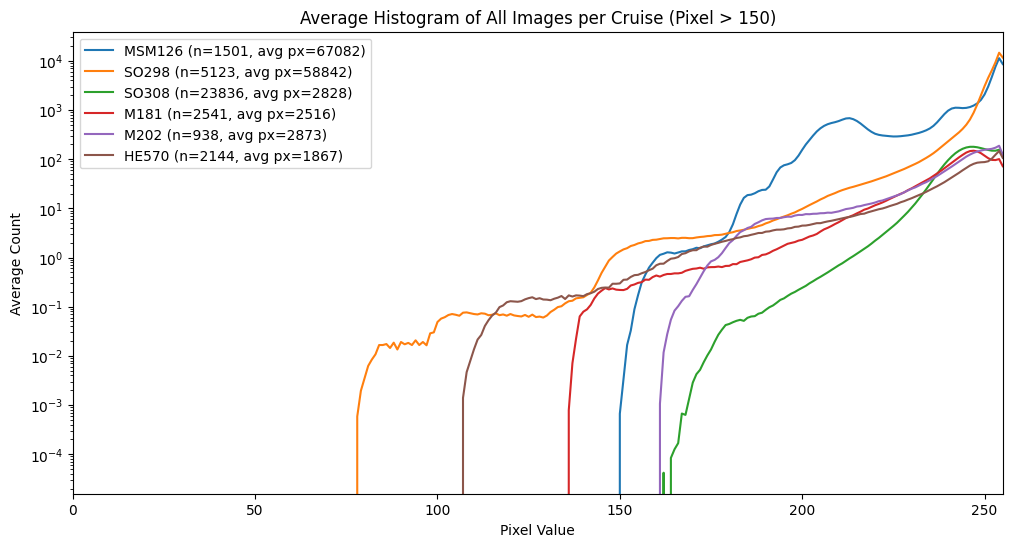

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

pred_path = "/home/veit/Documents/results/ViT_predictions.csv"
df = pd.read_csv(pred_path)

cruises = df['cruise'].unique()
n_bins = 256  # For 8-bit images

plt.figure(figsize=(12, 6))
for cruise in cruises:
    cruise_imgs = df[df['cruise'] == cruise]['filename']
    histograms = []
    sizes = []
    for fname in cruise_imgs:
        img_path = os.path.join("/home/veit/Documents/PIScO_benchmark_dataset", cruise, "Crops", fname)
        if os.path.exists(img_path):
            img = Image.open(img_path).convert("L")
            arr = np.array(img)
            #arr = arr[arr > 150]  # Only consider values above 150
            hist, _ = np.histogram(arr, bins=n_bins, range=(0, 255))
            histograms.append(hist)
            sizes.append(arr.size)
    support = len(histograms)
    avg_size = np.mean(sizes) if sizes else 0
    if support > 0:
        avg_hist = np.mean(histograms, axis=0)
        plt.plot(range(n_bins), avg_hist, label=f"{cruise} (n={support}, avg px={avg_size:.0f})")

plt.xlabel("Pixel Value")
plt.ylabel("Average Count")
plt.title("Average Histogram of All Images per Cruise ")
plt.xlim(0, 255)
plt.yscale('log')  # Set y-axis to log scale
plt.legend()
plt.show()

/tmp/ipykernel_1556183/1681405150.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)


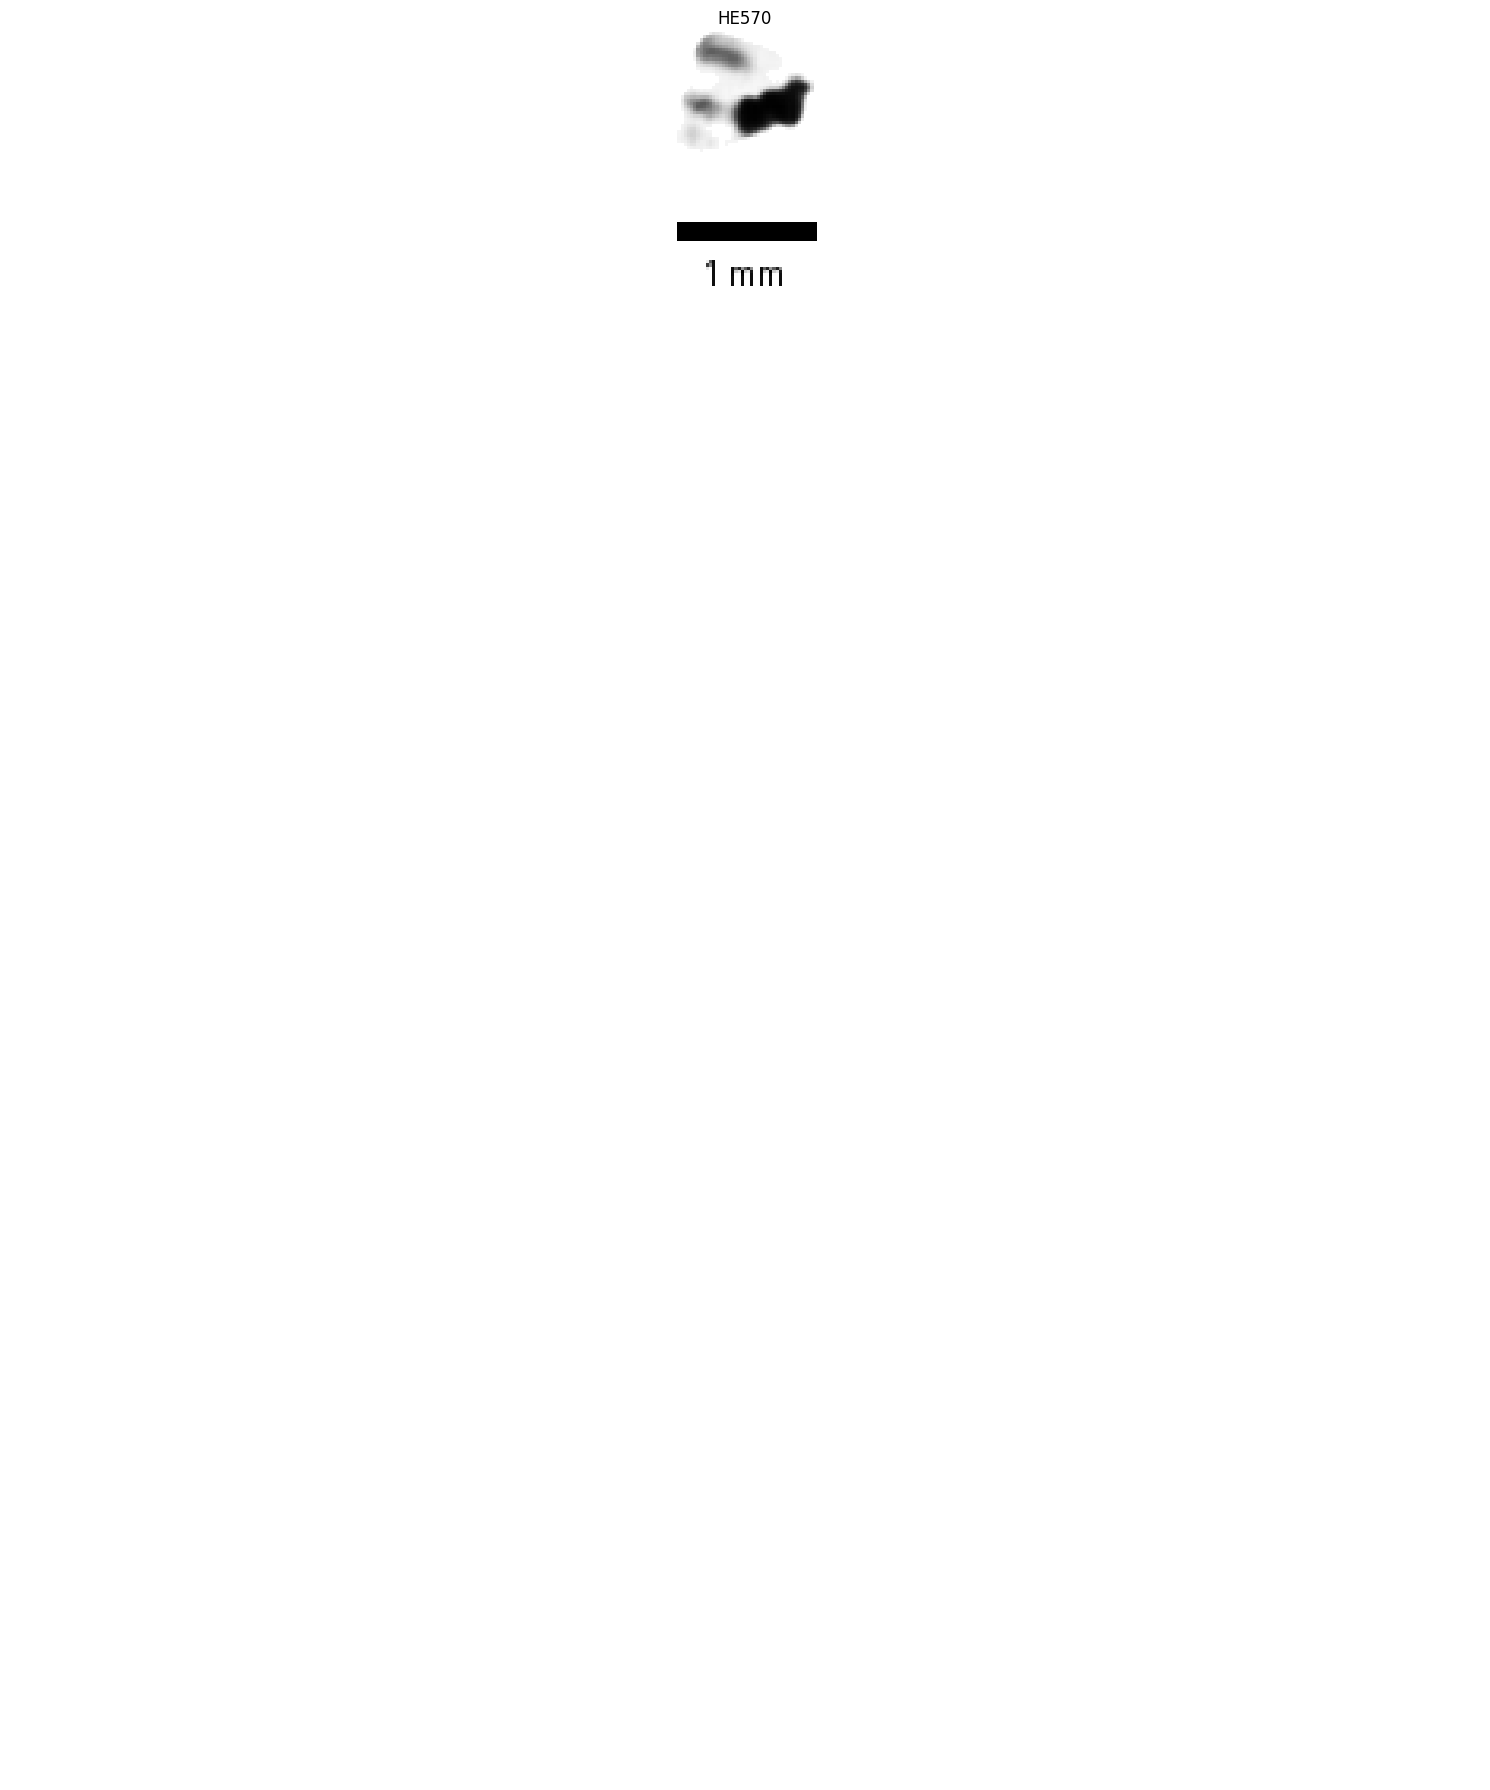

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import os

def add_scale_bar_to_pil(img, pixel_resolution=23, scale_length_mm=1):
    """
    Adds a scale bar below the PIL image and returns a new PIL image.
    """
    scale_length_px = int((scale_length_mm * 1000) / pixel_resolution)
    extra_height = 50
    bar_height = 5
    margin = 20

    min_width = scale_length_px + 2 * margin
    pad_left = pad_right = 0
    if img.width < min_width:
        pad_total = min_width - img.width
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        padded_img = Image.new("RGB", (min_width, img.height), "white")
        padded_img.paste(img.convert("RGB"), (pad_left, 0))
        img = padded_img

    new_img = Image.new("RGB", (img.width, img.height + extra_height), "white")
    new_img.paste(img, (0, 0))
    draw = ImageDraw.Draw(new_img)

    bar_x_start = margin
    bar_x_end = bar_x_start + scale_length_px
    bar_y_start = img.height + (extra_height - bar_height) // 2
    bar_y_end = bar_y_start + bar_height

    draw.rectangle([bar_x_start, bar_y_start, bar_x_end, bar_y_end], fill="black")

    text = f"{scale_length_mm} mm"
    font_size = 20
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()
    text_bbox = font.getbbox(text)
    text_width = text_bbox[2] - text_bbox[0]
    text_x = bar_x_start + (scale_length_px - text_width) // 2
    text_y = bar_y_end + 5
    draw.text((text_x, text_y), text, fill="black", font=font)

    return new_img

# --- Your plotting code with scale bar added ---

pred_path = "/home/veit/Documents/results/ViT_predictions.csv"
df = pd.read_csv(pred_path)
df_calanoida = df[df['top1'] == 'Calanoida']
sampled = df_calanoida.groupby('cruise').apply(lambda x: x.sample(min(5, len(x)), random_state=42)).reset_index(drop=True)

cruises = sampled['cruise'].unique()
n_cruises = len(cruises)
n_cols = 5

fig, axes = plt.subplots(n_cruises, n_cols, figsize=(3 * n_cols, 3 * n_cruises), squeeze=False)

for i, cruise in enumerate(cruises):
    cruise_samples = sampled[sampled['cruise'] == cruise].reset_index(drop=True)
    results_folders = glob.glob(os.path.join("/home/veit/Documents/PIScO_benchmark_dataset", cruise, "results_*"))
    if results_folders:
        results_folder = sorted(results_folders)[-1]  # or [0] for the first
    for j in range(n_cols):
        ax = axes[i, j]
        if j < len(cruise_samples):
            row = cruise_samples.iloc[j]
            img_path = os.path.join(results_folder, "Deconv_crops", row['filename'])
            #img_path = os.path.join("/home/veit/Documents/PIScO_benchmark_dataset", cruise, "results_*", "Crops", row['filename'])
            if os.path.exists(img_path):
                img = Image.open(img_path)
                img_with_bar = add_scale_bar_to_pil(img, pixel_resolution=23, scale_length_mm=1)
                ax.imshow(img_with_bar)
                ax.set_title(f"{cruise}")
            else:
                ax.set_facecolor('black')
            ax.axis('off')
        else:
            ax.axis('off')
    axes[i, 0].set_ylabel(cruise, rotation=0, size='large', labelpad=40, va='center')

plt.tight_layout()
plt.show()